In [1]:
import json
import os

data_path = os.path.join(os.getcwd(), "data_for_git")
query_clusters = []
with open(os.path.join(data_path, "all_query_clusters.jsonl"), "r") as f:
    for line in f:
        query_clusters.append(json.loads(line))

atomic_facts_data = []
with open(os.path.join(data_path, "atomic_facts.jsonl"), "r") as f:
    for line in f:
        atomic_facts_data.append(json.loads(line))
responses_data = []

original_generations = []
with open(os.path.join(data_path, "responses.jsonl"), "r") as f:
    for line in f:
        original_generations.append(json.loads(line))


for generation, query in zip(original_generations, query_clusters):
    query["prompt"] = generation["prompt"].split("CONTEXT>\nBased on the documents above, i now want you to:")[1]

In [2]:
def number_of_atomic_facts(cluster):
    return sum([len(c["atomic_facts"]) for c in cluster["clusters"]])


sort_by_number_of_atomic_facts = sorted(query_clusters, key=lambda x: number_of_atomic_facts(x), reverse=True)

n = 0
m = 100
for cluster in sort_by_number_of_atomic_facts:#[n:n+m]:
    cluster_type_counts = [0] * 5
    for c in cluster["clusters"]:
        cluster_type = len(set([f["from_sequence"] for f in c["atomic_facts"]]))
        cluster_type_counts[cluster_type-1] += 1
    if sum([cluster_type_counts[i]*(i+1) for i in range(5)]) > 300:
        print(cluster["prompt"])
        print(number_of_atomic_facts(cluster))
        print(sum([cluster_type_counts[i]*(i+1) for i in range(5)]))
        print(cluster_type_counts)
        print()



 Tell me a bio of Karl Urban., ANSWER:
419
348
[227, 26, 10, 6, 3]

 Tell me a bio of Deitrick Haddon., ANSWER:
372
361
[225, 29, 4, 14, 2]

 Tell me a bio of Maneka Gandhi., ANSWER:
354
319
[151, 38, 13, 7, 5]

 Tell me a bio of Roselyn Sánchez., ANSWER:
349
332
[163, 37, 15, 10, 2]

 Tell me a bio of Jeff Beukeboom., ANSWER:
342
330
[185, 39, 15, 3, 2]

 Tell me a bio of Patoranking., ANSWER:
341
334
[210, 26, 17, 4, 1]

 Tell me a bio of Andreas Ivanschitz., ANSWER:
338
323
[221, 24, 12, 2, 2]

 Tell me a bio of Florencia Bertotti., ANSWER:
333
314
[155, 24, 18, 8, 5]

 Tell me a bio of Kyra Sedgwick., ANSWER:
332
315
[179, 27, 8, 12, 2]

 Tell me a bio of David Wenham., ANSWER:
328
314
[165, 25, 21, 4, 4]

 Tell me a bio of Bella Akhmadulina., ANSWER:
326
311
[153, 30, 15, 12, 1]

 Tell me a bio of Melvin Van Peebles., ANSWER:
320
306
[155, 28, 12, 6, 7]

 Tell me a bio of Henry Santos., ANSWER:
319
316
[139, 28, 27, 5, 4]

 Tell me a bio of Ilhan Omar., ANSWER:
319
305
[173, 37, 1

In [3]:
sorted_by_number_of_atomic_facts = sorted(atomic_facts_data, key=lambda x: len(x["results"]["sentences_and_atomic_facts"]), reverse=True)

total_facts_for_original_query = {}

for generation in sorted_by_number_of_atomic_facts:
    original_query = generation["prompt"]
    if original_query not in total_facts_for_original_query:
        total_facts_for_original_query[original_query] = sum([len(f["atomic_facts"]) for f in generation["results"]["all_atomic_facts"]])
    else:
        total_facts_for_original_query[original_query] += sum([len(f["atomic_facts"]) for f in generation["results"]["all_atomic_facts"]])


sorted_by_total_facts = sorted(total_facts_for_original_query.items(), key=lambda x: x[1], reverse=True)

for query, total_facts in sorted_by_total_facts[:1]:
    print(query)
    print(total_facts)
    print()




Tell me a bio of Karl Urban.
419



In [4]:
from transformers import pipeline

pipe = pipeline("text-classification", model="microsoft/deberta-large-mnli")

Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [ ]:
str1 = "Francisco Urroz joined Unión Deportiva Española."
str2 = "Francisco Urroz began his professional football career with Unión Deportiva Española in 1931."
result = pipe([{"text": str1, "text_pair": str2}, {"text": str2, "text_pair": str1}], return_all_scores=True)
print("2 implies 1: ", result[0])
print("1 implies 2: ", result[1])

c:\Users\bpfwe\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


2 implies 1:  [{'label': 'CONTRADICTION', 'score': 0.00083991076098755}, {'label': 'NEUTRAL', 'score': 0.9955850839614868}, {'label': 'ENTAILMENT', 'score': 0.0035750102251768112}]
1 implies 2:  [{'label': 'CONTRADICTION', 'score': 0.0007087526028044522}, {'label': 'NEUTRAL', 'score': 0.004488879814743996}, {'label': 'ENTAILMENT', 'score': 0.9948023557662964}]


In [66]:
cluster_idx = 500
cluster = query_clusters[cluster_idx]
print(len(cluster["clusters"]))
for c in cluster["clusters"]:
    for f in c["atomic_facts"]:
        print(f["atomic_fact"])
    print()

59
Francisco Urroz Martínez was born on 14 December 1920.
Francisco Urroz Martínez was born on 14 December 1920.
Francisco Urroz Martínez was born on 14 December 1920.
Francisco Urroz Martínez was born on 14 December 1920
Francisco Urroz Martínez was born on 14 December 1920.

Francisco Urroz Martínez died on 22 January 1992.
Francisco Urroz Martínez died on 22 January 1992.
Francisco Urroz Martínez passed away on 22 January 1992.
Francisco Urroz Martínez passed away on 22 January 1992.
Francisco Urroz Martínez passed away on 22 January 1992.

Francisco Urroz Martínez was a Chilean.

Francisco Urroz Martínez was a footballer.

Francisco Urroz Martínez played as a defender.
Francisco Urroz Martínez played as a defender.

Francisco Urroz joined Unión Deportiva Española in 1931.
Francisco Urroz joined Unión Deportiva Española in 1931.
Francisco Urroz joined Unión Deportiva Española in 1931.
Francisco Urroz joined Unión Deportiva Española in 1931.

Francisco Urroz joined Unión Deportiva Es

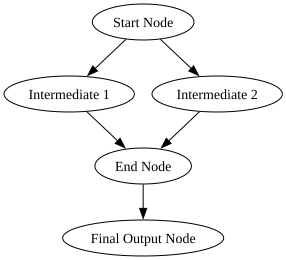

In [16]:
import graphviz

# Create a Directed Graph object
dot = graphviz.Digraph(comment='My Hierarchical DAG', graph_attr={'rankdir': 'TB'})

# Define the nodes (optional)
dot.node('A', 'Start Node')
dot.node('B', 'Intermediate 1')
dot.node('C', 'Intermediate 2')
dot.node('D', 'End Node')
dot.node('E', 'Final Output Node')

# Define the edges (demonstrating fan-in)
dot.edge('A', 'B')
dot.edge('A', 'C')
dot.edge('B', 'D')
dot.edge('C', 'D') # <- Node D has two parents (B and C)
dot.edge('D', 'E')

# Render the graph in the notebook
dot

In [23]:
def get_entailment_matrix(clusters):
    representatives = [c["representative"] for c in clusters]
    to_nli_model = []
    for rep in representatives:
        for other_rep in representatives:
            if rep["atomic_fact"] == other_rep["atomic_fact"]:
                continue
            to_nli_model.append({"text": rep["atomic_fact"], "text_pair": other_rep["atomic_fact"]})
    result = pipe(to_nli_model, return_all_scores=True)
    matrix = []
    counter = 0
    for i, rep in enumerate(representatives):
        row = []
        for j, other_rep in enumerate(representatives):
            if i == j:
                row.append(1)
            else:
                row.append(result[counter][2]["score"])
                counter += 1
        matrix.append(row)

    return matrix

chosen_clusters = query_clusters[0]["clusters"][:10]
matrix = get_entailment_matrix(chosen_clusters)
for row in matrix:
    print(row)

[1, 0.3662712275981903, 0.7496739029884338, 0.010857420973479748, 0.09491447359323502, 0.3496756851673126]
[0.00232049822807312, 1, 0.0018030748469755054, 0.008266140706837177, 0.07639212161302567, 0.010652199387550354]
[0.005936155095696449, 0.0016255989903584123, 1, 0.010796773247420788, 0.05820874869823456, 0.006254273001104593]
[0.15673166513442993, 0.049845002591609955, 0.8937192559242249, 1, 0.19187383353710175, 0.24768373370170593]
[0.0015592685667797923, 0.1915673315525055, 0.0006502079195342958, 0.002286482136696577, 1, 0.014606980606913567]
[0.0024084593169391155, 0.6223648190498352, 0.45407018065452576, 0.017604179680347443, 0.09306485950946808, 1]


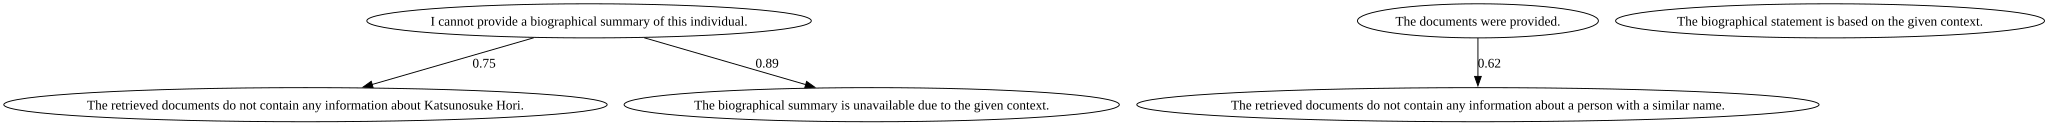

In [27]:
def visualize_hierarchy(matrix, clusters):
    dot = graphviz.Digraph(comment='My Hierarchical DAG', graph_attr={'rankdir': 'TB'})
    representatives = [c["representative"] for c in clusters]
    for rep, row in zip(representatives, matrix):
        dot.node(f'{rep["atomic_fact"]}', f'{rep["atomic_fact"]}')
        for other_rep, score in zip(representatives, row):
            if rep["atomic_fact"] == other_rep["atomic_fact"]:
                continue
            elif score > 0.5:
                dot.edge(f'{other_rep["atomic_fact"]}', f'{rep["atomic_fact"]}', label=f'{score:.2f}')
    return dot

visualize_hierarchy(matrix, chosen_clusters)

In [ ]:
# import statements here
